## How are in-demand skills trending?

### Methodology:

#### 1. Aggregate skill counts monthly
#### 2. Re-analyze based on percentage of total jobs
#### 3. Plot the monthly skill demand

In [1]:
# Importing libraries

import ast
import pandas as pd 
import seaborn as sns 
from datasets import load_dataset
import matplotlib.pyplot as plt 

# Loading data 

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data cleanup

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
# European jobs filter

european_countries = [
    'Albania', 'Andorra', 'Austria', 'Belarus', 'Belgium', 
    'Bosnia and Herzegovina', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia', 'Czech Republic', 
    'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 
    'Iceland', 'Ireland', 'Italy', 'Kosovo', 'Latvia', 'Liechtenstein', 
    'Lithuania', 'Luxembourg', 'Malta', 'Moldova', 'Monaco', 'Montenegro', 'Netherlands', 
    'North Macedonia', 'Norway', 'Poland', 'Portugal', 'Romania', 'Russia', 'San Marino', 
    'Serbia', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'Turkey', 
    'Ukraine', 'United Kingdom', 'UK', 'Vatican City'
]

# Condition to meet
df_europe = df[df['job_country'].isin(european_countries)]

In [3]:
df_europe['job_posted_month_no'] = df_europe['job_posted_date'].dt.month

In [4]:
df_europe_explode = df_europe.explode('job_skills')

In [8]:
df_europe_pivot = df_europe_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0 )

df_europe_pivot.loc['Total'] = df_europe_pivot.sum()

df_europe_pivot = df_europe_pivot[df_europe_pivot.loc['Total'].sort_values(ascending=False).index]

df_europe_pivot = df_europe_pivot.drop('Total')

df_europe_pivot

job_skills,python,sql,azure,aws,r,spark,power bi,excel,tableau,java,...,workfront,ember.js,ringcentral,nuxt.js,chainer,dingtalk,huggingface,esquisse,deno,wimi
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,17856,16778,7235,6498,5074,5307,4339,4436,4278,3793,...,0,1,1,1,0,0,0,0,0,0
2,12574,12131,5136,4486,3593,3709,3328,3328,3352,2597,...,2,0,1,0,0,0,0,0,0,0
3,12275,11351,4882,4349,3543,3546,3095,3132,3119,2658,...,0,0,0,0,1,0,0,0,1,0
4,11300,10598,4506,3997,3197,3213,2965,2984,2807,2422,...,1,2,0,0,1,0,0,0,0,0
5,9538,9027,3754,3493,2662,2631,2536,2461,2434,1831,...,0,0,2,0,0,0,0,0,0,0
6,11211,10515,4356,3892,3152,3089,3085,3026,2828,2151,...,0,0,0,0,0,0,0,0,0,0
7,11035,10453,4449,4007,3158,2866,3195,3014,2889,2082,...,0,0,0,0,0,0,0,0,0,0
8,11737,10948,4746,4364,3168,3145,3026,3085,2829,2317,...,1,0,0,0,0,0,0,0,0,0
9,10142,9625,4211,3674,2670,2715,2880,2761,2426,1894,...,0,0,0,0,0,0,1,0,0,0


In [12]:
df_total = df_europe.groupby('job_posted_month_no').size()

df_total

job_posted_month_no
1     36270
2     26067
3     24667
4     23257
5     19075
6     22423
7     22905
8     24859
9     22643
10    24976
11    23714
12    20296
dtype: int64

In [14]:
df_europe_perc = df_europe_pivot.div(df_total/100, axis=0)

In [15]:
# changes month number to month name
df_europe_perc = df_europe_perc.reset_index()
df_europe_perc['job_posted_month'] = df_europe_perc['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_europe_perc = df_europe_perc.set_index('job_posted_month')
df_europe_perc = df_europe_perc.drop(columns='job_posted_month_no')

df_europe_perc

job_skills,python,sql,azure,aws,r,spark,power bi,excel,tableau,java,...,workfront,ember.js,ringcentral,nuxt.js,chainer,dingtalk,huggingface,esquisse,deno,wimi
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,49.230769,46.258616,19.947615,17.915633,13.989523,14.631927,11.963055,12.230494,11.794872,10.457679,...,0.000000,0.002757,0.002757,0.002757,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,48.237235,46.537768,19.703073,17.209499,13.783711,14.228718,12.767100,12.767100,12.859171,9.962788,...,0.007673,0.000000,0.003836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,49.762841,46.016946,19.791624,17.630843,14.363319,14.375481,12.547128,12.697126,12.644424,10.775530,...,0.000000,0.000000,0.000000,0.000000,0.004054,0.000000,0.000000,0.000000,0.004054,0.000000
Apr,48.587522,45.569076,19.374812,17.186224,13.746399,13.815195,12.748850,12.830546,12.069484,10.414069,...,0.004300,0.008600,0.000000,0.000000,0.004300,0.000000,0.000000,0.000000,0.000000,0.000000
May,50.002621,47.323722,19.680210,18.311927,13.955439,13.792923,13.294889,12.901704,12.760157,9.598952,...,0.000000,0.000000,0.010485,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,49.997770,46.893814,19.426482,17.357178,14.056995,13.776034,13.758195,13.495072,12.612050,9.592829,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,48.177254,45.636324,19.423707,17.493997,13.787383,12.512552,13.948919,13.158699,12.612967,9.089718,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,47.214289,44.040388,19.091677,17.555010,12.743875,12.651354,12.172654,12.409992,11.380184,9.320568,...,0.004023,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Sep,44.790885,42.507618,18.597359,16.225765,11.791724,11.990461,12.719163,12.193614,10.714128,8.364616,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.004416,0.000000,0.000000,0.000000


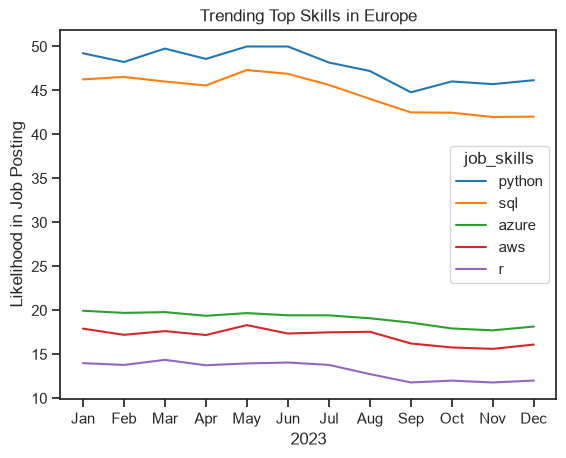

In [20]:
df_plot = df_europe_perc.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')

plt.title('Trending Top Skills in Europe')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.show()